In [1]:
import pandas as pd
df = pd.read_csv(r'C:\Users\SIDHARTH\Downloads\Main project\books 7.csv')
df.head(5)

,asin,reviewText,overall,category,summary
0,0991434897,-Very good overview of experiments showing pla...,3.0,Books_5,Uncertain
1,0991434897,These techniques really work. I got rid of fo...,5.0,Books_5,Very helpful!
2,0991434897,"Got dry at points, But its about the content n...",5.0,Books_5,You Want Change? Your mind is the tool and thi...
3,0991434897,good stuff,5.0,Books_5,powerful
4,0991520904,Moooooooore!! I absolutely love this series!! ...,5.0,Books_5,Body Movers


In [2]:
df.tail(5)

,asin,reviewText,overall,category,summary
3988731,1494734508,This password book is soft cover and is a grea...,5.0,Books_5,Perfect Size!
3988732,1494707748,The love story between Caleo and Jack is simpl...,4.0,Books_5,The love story between Caleo and Jack is simpl...
3988733,1494707748,Proofreader!!! Did the proofreader get slaught...,3.0,Books_5,PROOFREADER!!!
3988734,1494707748,"Wow, great series! I can't wait to go on more ...",5.0,Books_5,ready for book 3
3988735,1494707748,When I finished the first book I could hardly ...,5.0,Books_5,Another amazing book by Mr. Crawford.


In [3]:
df.shape

(3988736, 5)

In [4]:
df.sample(5)

,asin,reviewText,overall,category,summary
2178224,1462117465,"Wow, there really is a lot going on in this bo...",4.0,Books_5,"I liked Aerbrin, she is a great character"
3917708,1493684868,This book shines light on many overlooked issu...,4.0,Books_5,Great Read
2168577,1461154472,"This was a light, fun read. Having been to Veg...",5.0,Books_5,Fun read
1153313,1416980067,I love these kinds of books because its the sa...,5.0,Books_5,Awsome book!
443905,1250030935,Sandra Dalles is a fine writer of Colo. histor...,5.0,Books_5,Falling for Fallen Women


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3988736 entries, 0 to 3988735
Data columns (total 5 columns):
 #   Column      Dtype  
---  ------      -----  
 0   asin        object 
 1   reviewText  object 
 2   overall     float64
 3   category    object 
 4   summary     object 
dtypes: float64(1), object(4)
memory usage: 152.2+ MB


In [6]:
df.columns

Index(['asin', 'reviewText', 'overall', 'category', 'summary'], dtype='object')

Rating Distribution

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


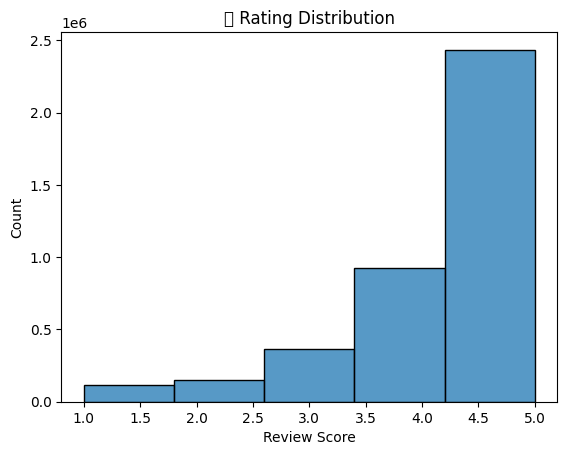

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['overall'], bins=5)
plt.title("📈 Rating Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()


Review Length vs. Rating

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


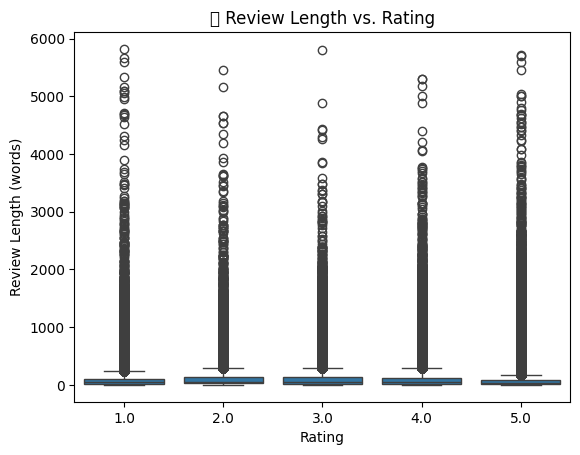

In [8]:
df['length'] = df['reviewText'].fillna('').apply(lambda x: len(x.split()))

sns.boxplot(data=df, x='overall', y='length')
plt.title("📝 Review Length vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (words)")
plt.show()



Category-Level Rating Trends

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


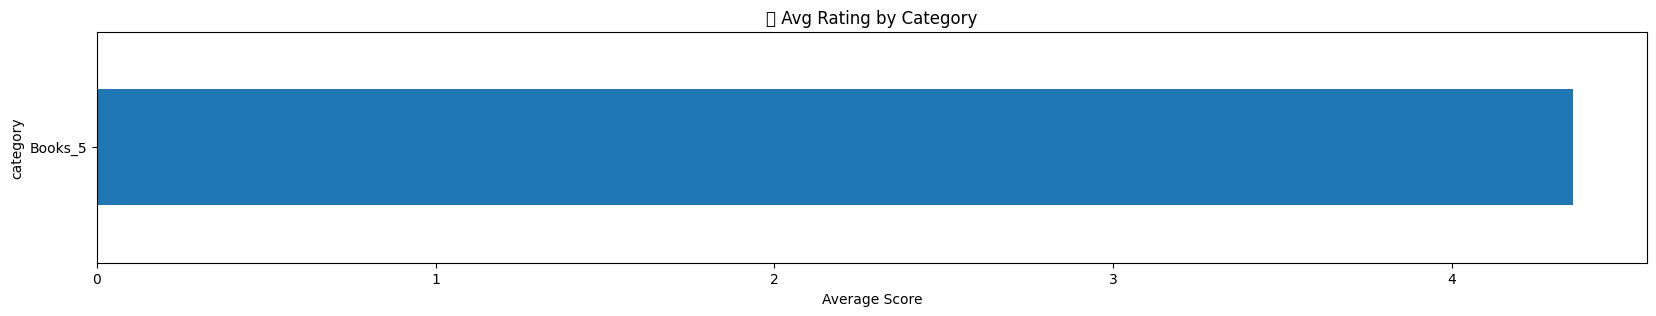

In [9]:
category_avg = df.groupby('category')['overall'].mean().sort_values()
category_avg.plot(kind='barh', figsize=(20, 3), title="📚 Avg Rating by Category")
plt.xlabel("Average Score")
plt.show()



In [10]:
df.drop(columns=['asin',  'category', 'summary'],inplace=True)

In [11]:
df.columns

Index(['reviewText', 'overall', 'length'], dtype='object')

In [12]:
df.isnull().sum()

reviewText    125
overall         0
length          0
dtype: int64

In [13]:
df.dropna(inplace=True)

In [14]:
df.isnull().sum()

reviewText    0
overall       0
length        0
dtype: int64

In [15]:
df.rename(columns={'reviewText':'review','overall':'rating'},inplace=True)

In [16]:
df.head(5)

,review,rating,length
0,-Very good overview of experiments showing pla...,3.0,150
1,These techniques really work. I got rid of fo...,5.0,16
2,"Got dry at points, But its about the content n...",5.0,38
3,good stuff,5.0,2
4,Moooooooore!! I absolutely love this series!! ...,5.0,31


In [17]:
print(df.duplicated().sum())

189328


In [18]:
df.drop_duplicates(subset=['review','rating'],inplace=True)

In [19]:
print(df.duplicated().sum())

0


In [20]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df.loc[:, "review"] = df["review"].apply(clean_text)

In [21]:
df['rating']=df['rating'].astype(int)

In [22]:
df['rating'].value_counts()

rating
5    2293227
4     893129
3     354093
2     145597
1     113237
Name: count, dtype: int64

In [23]:
df.shape

(3799283, 3)

In [24]:
df.sample(5)

,review,rating,length
298445,first thank you to netgalley random houseballe...,4,121
3403607,great recipesgood infoeasy explanations on eac...,5,20
599273,well into the kindle edition and worth the inv...,5,146
826305,humphreys has created a new world of shifters ...,5,39
1902782,great story and well written highly recommend,4,7


In [25]:
df.to_csv('D-BOOKS - 7 DL.csv',index=False)